<a href="https://colab.research.google.com/github/ajithpalanisamy321-commits/indianmovies26/blob/main/NAVEEN_MILESTONE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CELL 1 — Install Required Libraries

In [ ]:
!pip install tensorflow opencv-python matplotlib scikit-learn tqdm seaborn kagglehub


**CELL 2 — Import Libraries**

In [ ]:
# ===============================
# Core Libraries
# ===============================
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ===============================
# Scikit-learn
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# ===============================
# TensorFlow / Keras
# ===============================
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, LSTM,
    TimeDistributed, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


CELL 3 — Download UCF101 Frames Dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("pevogam/ucf101-frames")
print("Dataset path:", path)


Resuming download from 484442112 bytes (9018914984 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/pevogam/ucf101-frames?dataset_version_number=2 (484442112/9503357096) bytes left.


100%|██████████| 8.85G/8.85G [01:47<00:00, 84.0MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/pevogam/ucf101-frames/versions/2


CELL 4 — Project Parameters

In [ ]:
IMG_SIZE = 96
SEQUENCE_LENGTH = 8
NUM_CLASSES = 4
VIDEOS_PER_CLASS = 30
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


Select 10 Action **Categories** **bold text**

In [ ]:
DATASET_PATH = os.path.join(path, "train")

SELECTED_CLASSES = [
    "JumpingJack",
    "PushUps",
    "PullUps",
    "WalkingWithDog"
]

print("Selected Classes:")
for c in SELECTED_CLASSES:
    print("-", c)


Selected Classes:
- JumpingJack
- PushUps
- PullUps
- WalkingWithDog


**Dataset Sampling (10 × 100 Videos)**

In [ ]:
def sample_videos(dataset_path, classes, max_videos):
    video_data, labels = [], []

    for label in classes:
        class_path = os.path.join(dataset_path, label)
        frames = os.listdir(class_path)

        video_ids = list(set(f.split('-')[0] for f in frames if f.endswith(".jpg")))
        random.shuffle(video_ids)

        for vid in video_ids[:max_videos]:
            video_data.append((vid, class_path))
            labels.append(label)

    return video_data, labels


video_data, video_labels = sample_videos(
    DATASET_PATH, SELECTED_CLASSES, VIDEOS_PER_CLASS
)

print("Total videos:", len(video_data))


Total videos: 120


CELL 7 — Frame Loading & **Preprocessing** **bold text**

In [ ]:
def load_video(video_id, class_path):
    frames = sorted([
        f for f in os.listdir(class_path)
        if f.startswith(video_id) and f.endswith(".jpg")
    ])[:SEQUENCE_LENGTH]

    sequence = []

    for f in frames:
        img = cv2.imread(os.path.join(class_path, f))
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        sequence.append(img)

    while len(sequence) < SEQUENCE_LENGTH:
        sequence.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))

    return np.array(sequence)


In [ ]:
X, y = [], []

for (vid, path_), label in tqdm(zip(video_data, video_labels), total=len(video_data)):
    X.append(load_video(vid, path_))
    y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


100%|██████████| 120/120 [00:02<00:00, 52.26it/s]


X shape: (120, 8, 96, 96, 3)
y shape: (120,)


**CELL 8 — Label Encoding & Split**

In [ ]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_cat, test_size=0.25, random_state=RANDOM_SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=RANDOM_SEED
)


**MODEL 1 — CNN ONLY (Baseline)**

In [ ]:
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    X_train[:,0],
    y_train,
    validation_data=(X_val[:,0], y_val),
    epochs=8,
    batch_size=32
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 456ms/step - accuracy: 0.1654 - loss: 1.9899 - val_accuracy: 0.2222 - val_loss: 1.5672
Epoch 2/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 326ms/step - accuracy: 0.2439 - loss: 1.5873 - val_accuracy: 0.1667 - val_loss: 1.4731
Epoch 3/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step - accuracy: 0.3346 - loss: 1.3441 - val_accuracy: 0.3333 - val_loss: 1.3493
Epoch 4/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 443ms/step - accuracy: 0.5343 - loss: 1.2692 - val_accuracy: 0.3889 - val_loss: 1.3157
Epoch 5/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6406 - loss: 1.1784 - val_accuracy: 0.2778 - val_loss: 1.3336
Epoch 6/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step - accuracy: 0.6319 - loss: 1.1183 - val_accuracy: 0.4444 - val_loss: 1.2336
Epoch 7/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step - accuracy: 0.7166 - loss: 0.9654 - val_accuracy: 0.4444 - val_loss: 1.1460
Epoch 8/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step - accuracy: 0.7096 - loss: 0.8126 - val_accuracy: 0.6111 - val_loss: 1.0675


**MODEL 2 — RNN / LSTM / GRU**

In [ ]:
feature_extractor = Model(
    inputs=cnn.inputs[0],
    outputs=cnn.layers[-3].output
)

def extract_features(X):
    return np.array([
        [feature_extractor.predict(frame[np.newaxis,...], verbose=0)[0]
         for frame in video]
        for video in tqdm(X)
    ])

In [ ]:
X_train_f = extract_features(X_train)
X_val_f   = extract_features(X_val)
X_test_f  = extract_features(X_test)


100%|██████████| 30/30 [00:26<00:00,  1.15it/s]


In [ ]:
lstm_model = Sequential([
    Input(shape=(SEQUENCE_LENGTH, X_train_f.shape[2])),
    LSTM(128),
    Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.fit(
    X_train_f, y_train,
    validation_data=(X_val_f, y_val),
    epochs=10,
    batch_size=32
)


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 226ms/step - accuracy: 0.3724 - loss: 1.4061 - val_accuracy: 0.3889 - val_loss: 1.3775
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6862 - loss: 1.1169 - val_accuracy: 0.3889 - val_loss: 1.3003
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8325 - loss: 0.8877 - val_accuracy: 0.4444 - val_loss: 1.2487
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8641 - loss: 0.7078 - val_accuracy: 0.3889 - val_loss: 1.2425
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8650 - loss: 0.5495 - val_accuracy: 0.3889 - val_loss: 1.3092
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8702 - loss: 0.4619 - val_accuracy: 0.5000 - val_loss: 1.4226
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9115 - loss: 0.3618 - val_accuracy: 0.5000 - val_loss: 1.5438
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9193 - loss: 0.3299 - val_accuracy: 0.5000 - val_loss: 1.5126

**MODEL 3 — CNN + LSTM HYBRID**

In [ ]:
input_layer = Input(shape=(SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3))

x = TimeDistributed(Conv2D(32, (3,3), activation='relu'))(input_layer)
x = TimeDistributed(MaxPooling2D())(x)
x = TimeDistributed(Conv2D(64, (3,3), activation='relu'))(x)
x = TimeDistributed(MaxPooling2D())(x)
x = TimeDistributed(Flatten())(x)

x = LSTM(128)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

hybrid_model = Model(input_layer, output)

hybrid_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hybrid_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=8
)


Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.2095 - loss: 2.1062 - val_accuracy: 0.1667 - val_loss: 1.5866
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.1972 - loss: 1.4394 - val_accuracy: 0.1111 - val_loss: 1.5061
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.3265 - loss: 1.4011 - val_accuracy: 0.2222 - val_loss: 1.4183
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.4084 - loss: 1.3312 - val_accuracy: 0.2222 - val_loss: 1.4590
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.4107 - loss: 1.2983 - val_accuracy: 0.2778 - val_loss: 1.3884
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.4262 - loss: 1.2204 - val_accuracy: 0.2222 - val_loss: 1.3788
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.5391 - loss: 1.1666 - val_accuracy: 0.2778 - val_loss: 1.3463
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.5334 - loss: 1.1039 - val_accuracy: 0.3333 - val_loss: 1.3779
Epoch 9/

** EVALUATION & COMPARISON**

In [ ]:
def evaluate_model(model, X, y, title):
    y_pred = np.argmax(model.predict(X), axis=1)
    y_true = np.argmax(y, axis=1)

    print(title)
    print(classification_report(y_true, y_pred, target_names=encoder.classes_))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, cmap="Blues",
                xticklabels=encoder.classes_,
                yticklabels=encoder.classes_)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
CNN Baseline
                precision    recall  f1-score   support

   JumpingJack       0.60      0.75      0.67         8
       PullUps       0.73      1.00      0.84         8
       PushUps       1.00      0.50      0.67         8
WalkingWithDog       0.60      0.50      0.55         6

      accuracy                           0.70        30
     macro avg       0.73      0.69      0.68        30
  weighted avg       0.74      0.70      0.69        30



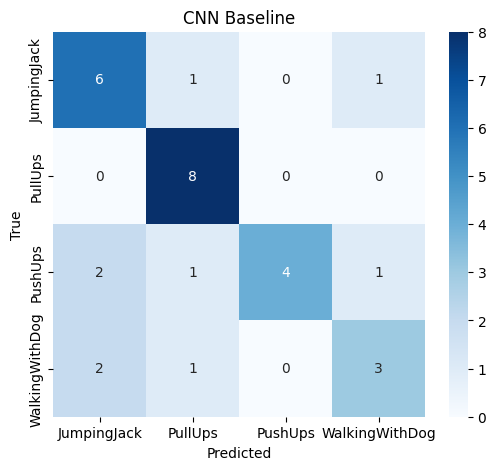

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
CNN + LSTM
                precision    recall  f1-score   support

   JumpingJack       0.75      0.38      0.50         8
       PullUps       0.78      0.88      0.82         8
       PushUps       1.00      0.50      0.67         8
WalkingWithDog       0.46      1.00      0.63         6

      accuracy                           0.67        30
     macro avg       0.75      0.69      0.66        30
  weighted avg       0.77      0.67      0.66        30



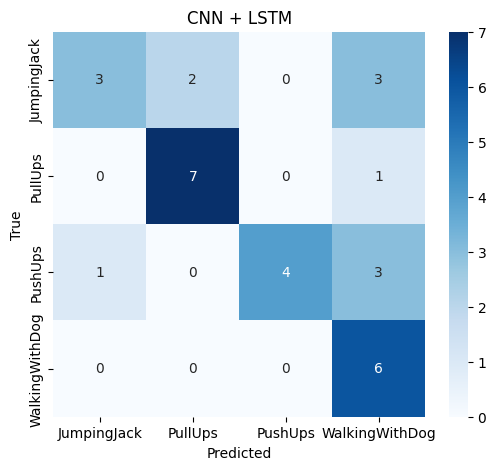

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Hybrid CNN-LSTM
                precision    recall  f1-score   support

   JumpingJack       0.00      0.00      0.00         8
       PullUps       0.33      1.00      0.50         8
       PushUps       0.00      0.00      0.00         8
WalkingWithDog       0.75      0.50      0.60         6

      accuracy                           0.37        30
     macro avg       0.27      0.38      0.28        30
  weighted avg       0.24      0.37      0.25        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


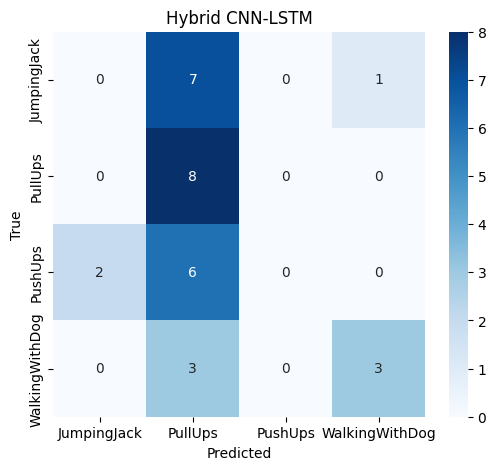

In [ ]:
evaluate_model(cnn, X_test[:,0], y_test, "CNN Baseline")
evaluate_model(lstm_model, X_test_f, y_test, "CNN + LSTM")
evaluate_model(hybrid_model, X_test, y_test, "Hybrid CNN-LSTM")


In [ ]:
cnn.save("cnn_baseline.keras")
lstm_model.save("lstm_model.keras")
hybrid_model.save("cnn_lstm_hybrid.keras")
